In [4]:
import pandas as pd
import scipy.stats
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt

Assignment 1

In [5]:
df=pd.read_csv('/Users/melanyalegre/Documents/International Business/Minor documents/Data Modelling/1645634boston.csv')
df.dropna()
df.head()


,MEDV,CRIM,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LANDMARK
0,300,51.13580,18.10,no,0.597,5.757,100.0,1.4130,24,666,20.2,No Landmark
1,230,8.15174,18.10,no,0.700,5.390,98.9,1.7281,24,666,20.2,No Landmark
2,278,15.28800,18.10,no,0.671,6.649,93.3,1.3449,24,666,20.2,No Landmark
3,424,0.23912,9.69,no,0.585,6.019,65.3,2.4091,6,391,19.2,No Landmark
4,270,1.61282,8.14,no,0.538,6.096,96.9,3.7598,4,307,21.0,No Landmark


Correlation Heatmap

In [6]:
#MEDV,RM,AGE
data=df[['MEDV','RM','AGE']]
matrix=data.corr()
print(matrix)

          MEDV        RM       AGE
MEDV  1.000000  0.733064 -0.386466
RM    0.733064  1.000000 -0.234385
AGE  -0.386466 -0.234385  1.000000


<Axes: >

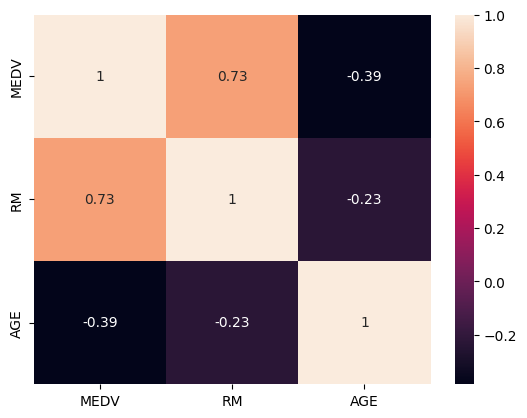

In [7]:
sn.heatmap(matrix,annot=True)

Multiple Linear Regression

In [8]:
print(df.columns.tolist())


['MEDV', 'CRIM', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'LANDMARK']


In [9]:
import statsmodels.formula.api as sm
model2=sm.ols('MEDV~CRIM+INDUS+CHAS+NOX+RM+AGE+DIS+RAD+TAX+PTRATIO+LANDMARK',data=df).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.890
Model:                            OLS   Adj. R-squared:                  0.886
Method:                 Least Squares   F-statistic:                     253.2
Date:                Mon, 20 Oct 2025   Prob (F-statistic):          2.54e-200
Time:                        17:26:00   Log-Likelihood:                -2518.2
No. Observations:                 455   AIC:                             5066.
Df Residuals:                     440   BIC:                             5128.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [24]:
df=pd.read_csv('/Users/melanyalegre/Documents/International Business/Minor documents/Data Modelling/1645634boston.csv')
df = pd.get_dummies(df, dtype=int)
df.head()

,MEDV,CRIM,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,CHAS_no,CHAS_yes,LANDMARK_Museum,LANDMARK_No Landmark,LANDMARK_Park,LANDMARK_Shopping Mall,LANDMARK_Stadium
0,300,51.13580,18.10,0.597,5.757,100.0,1.4130,24,666,20.2,1,0,0,1,0,0,0
1,230,8.15174,18.10,0.700,5.390,98.9,1.7281,24,666,20.2,1,0,0,1,0,0,0
2,278,15.28800,18.10,0.671,6.649,93.3,1.3449,24,666,20.2,1,0,0,1,0,0,0
3,424,0.23912,9.69,0.585,6.019,65.3,2.4091,6,391,19.2,1,0,0,1,0,0,0
4,270,1.61282,8.14,0.538,6.096,96.9,3.7598,4,307,21.0,1,0,0,1,0,0,0


In [25]:
print(df.columns.tolist())


['MEDV', 'CRIM', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'CHAS_no', 'CHAS_yes', 'LANDMARK_Museum', 'LANDMARK_No Landmark', 'LANDMARK_Park', 'LANDMARK_Shopping Mall', 'LANDMARK_Stadium']


Multicollinearity

In [27]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif 
from statsmodels.tools.tools import add_constant

X=df[[ 'CRIM', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'CHAS_yes', 'LANDMARK_No Landmark', 'LANDMARK_Park', 'LANDMARK_Shopping Mall', 'LANDMARK_Stadium']].dropna()
X=add_constant(X)

VIF_data=pd.DataFrame()
VIF_data['Variable']=X.columns
VIF_data['VIF']=[vif(X,i)
                 for i in range (len(X.columns))]
print(VIF_data)

                  Variable         VIF
0                    const  604.093490
1                     CRIM    1.895099
2                    INDUS    4.182688
3                      NOX    4.492071
4                       RM    2.212531
5                      AGE    2.786017
6                      DIS    3.576689
7                      RAD    7.394288
8                      TAX    8.429543
9                  PTRATIO    1.822294
10                CHAS_yes    1.094462
11    LANDMARK_No Landmark   13.932159
12           LANDMARK_Park    7.437757
13  LANDMARK_Shopping Mall    6.498547
14        LANDMARK_Stadium    2.169292


In [28]:
import statsmodels.formula.api as sm
df.columns = df.columns.str.replace(' ', '_', regex=False)
model3=sm.ols('MEDV~CRIM+INDUS+CHAS_yes+NOX+RM+AGE+DIS+TAX+PTRATIO+LANDMARK_Park+LANDMARK_Shopping_Mall+LANDMARK_Stadium',data=df).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.773
Model:                            OLS   Adj. R-squared:                  0.766
Method:                 Least Squares   F-statistic:                     125.2
Date:                Mon, 20 Oct 2025   Prob (F-statistic):          8.99e-134
Time:                        18:45:51   Log-Likelihood:                -2682.5
No. Observations:                 455   AIC:                             5391.
Df Residuals:                     442   BIC:                             5445.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                407

In [14]:
pip install Stargazer

Note: you may need to restart the kernel to use updated packages.


In [15]:
from stargazer.stargazer import Stargazer
from IPython.core.display import HTML

Table = Stargazer([model2,model3])

HTML(Table.render_html())

Assignment 2

In [16]:
from sklearn.preprocessing import StandardScaler

In [18]:
df_s=df.copy()
df_s[['CRIM','RM']]=StandardScaler().fit_transform(df_s[['CRIM','RM']])

In [23]:
import statsmodels.formula.api as sm
df.columns = df.columns.str.replace(' ', '_', regex=False)
model4=sm.ols('MEDV~CRIM+RM',data=df).fit()
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.590
Model:                            OLS   Adj. R-squared:                  0.588
Method:                 Least Squares   F-statistic:                     325.2
Date:                Mon, 20 Oct 2025   Prob (F-statistic):           3.09e-88
Time:                        17:31:36   Log-Likelihood:                -2816.7
No. Observations:                 455   AIC:                             5639.
Df Residuals:                     452   BIC:                             5652.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -625.9539     52.066    -12.022      0.0